### Stage I: Solve for best $r$ and $c$ given $s$
For each $s$, we solve for $r^*$ and $c^*$, and find the break_even multiplier $m_{\text{BE}}(s)$.

In [3]:
import math
import numpy as np

BUDGET = 50_000.0
LOG101 = math.log(101.0)


def research(r: float) -> float:
    """Research outcome for allocation fraction r in [0,1]."""
    if r < 0 or r > 1:
        return -float("inf")
    return 200_000.0 * math.log(1.0 + 100.0 * r) / LOG101


def scale(c: float) -> float:
    """Scale outcome for allocation fraction c in [0,1]."""
    if c < 0 or c > 1:
        return -float("inf")
    return 7.0 * c


def productive_power(r: float, c: float) -> float:
    """
    A = Research(r) * Scale(c)
    so that PnL = A * m - BUDGET * (r + c + s).
    """
    if min(r, c) < 0 or r > 1 or c > 1:
        return -float("inf")
    return research(r) * scale(c)


def break_even_multiplier(r: float, c: float, s: float) -> float:
    """
    Break-even multiplier m_BE solves
        Research(r) * Scale(c) * m_BE = BUDGET * (r + c + s)
    so
        m_BE = BUDGET * (r + c + s) / (Research(r) * Scale(c))
    In the optimum here, r + c + s = 1, so this reduces to
        m_BE = BUDGET / A.
    """
    A = productive_power(r, c)
    if A <= 0:
        return float("inf")
    return BUDGET * (r + c + s) / A


def pnl(r: float, c: float, s: float, m: float) -> float:
    """
    Full PnL:
        Research(r) * Scale(c) * m - 50_000 * (r + c + s)
    """
    if min(r, c, s) < 0 or r + c + s > 1:
        return -float("inf")
    return research(r) * scale(c) * m - BUDGET * (r + c + s)


def first_order_equation(r: float, s: float) -> float:
    """
    This is f'(r) for f(r) = (1 - s - r) * log(1 + 100r):
        f'(r) = -log(1 + 100r) + 100(1 - s - r)/(1 + 100r)
    The optimizer solves f'(r) = 0.
    """
    return -math.log(1.0 + 100.0 * r) + 100.0 * (1.0 - s - r) / (1.0 + 100.0 * r)


def solve_r_for_fixed_s(s: float, tol: float = 1e-12, max_iter: int = 1000) -> float:
    """
    Solve f'(r)=0 on [0, 1-s] by bisection.
    This gives the optimal r when s is fixed and c = 1 - s - r.
    """
    if not (0.0 <= s <= 1.0):
        raise ValueError("s must lie in [0,1].")

    # If no budget remains, r = 0
    if s >= 1.0:
        return 0.0

    left = 0.0
    right = 1.0 - s

    f_left = first_order_equation(left, s)
    f_right = first_order_equation(right, s)

    # In this problem, f_left > 0 and f_right < 0 typically.
    # If not, fall back to endpoint comparison.
    if f_left <= 0:
        return left
    if f_right >= 0:
        return right

    for _ in range(max_iter):
        mid = 0.5 * (left + right)
        f_mid = first_order_equation(mid, s)

        if abs(f_mid) < tol or (right - left) < tol:
            return mid

        if f_mid > 0:
            left = mid
        else:
            right = mid

    return 0.5 * (left + right)


def solve_fixed_s(s: float, m: float) -> tuple[float, float, float]:
    """
    For fixed speed allocation s and fixed speed multiplier m,
    solve for optimal r and c.
    Since the optimum uses all remaining non-speed budget,
        c = 1 - s - r.
    """
    r_star = solve_r_for_fixed_s(s)
    c_star = 1.0 - s - r_star
    val = pnl(r_star, c_star, s, m)
    return r_star, c_star, val


def scan_over_s(m: float, n_grid: int = 1001) -> tuple[float, float, float, float]:
    """
    Scan s over a grid in [0,1], and for each s solve the inner problem.
    Returns:
        (best_r, best_c, best_s, best_pnl)
    """
    best = None

    for s in np.linspace(0.0, 1.0, n_grid):
        r_star, c_star, val = solve_fixed_s(float(s), m)
        if best is None or val > best[3]:
            best = (r_star, c_star, float(s), val)

    return best


if __name__ == "__main__":
    # Example 1: reproduce the optimal r for some fixed s values
    test_s_values = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
    example_m = 0.5  # any positive m gives the same r* for fixed s

    print("Optimal (r, c), productive power A, and break-even multiplier m_BE for fixed s:")
    for s in test_s_values:
        r_star, c_star, val = solve_fixed_s(s, example_m)
        A = productive_power(r_star, c_star)
        m_be = break_even_multiplier(r_star, c_star, s)
        print(
            f"s = {s:>4.2f} | "
            f"r* = {r_star:.6f}, "
            f"c* = {c_star:.6f}, "
            f"A = {A:,.2f}, "
            f"m_BE = {m_be:.6f}, "
            f"PnL(m={example_m:.1f}) = {val:,.2f}"
        )

    print("\nScanning over s for a chosen multiplier m:")
    for m in [0.1, 0.3, 0.5, 0.7, 0.9]:
        best_r, best_c, best_s, best_val = scan_over_s(m, n_grid=2001)
        best_m_be = break_even_multiplier(best_r, best_c, best_s)
        print(
            f"m = {m:.1f} | "
            f"best r = {best_r:.6f}, "
            f"best c = {best_c:.6f}, "
            f"best s = {best_s:.6f}, "
            f"best m_BE = {best_m_be:.6f}, "
            f"best PnL = {best_val:,.2f}"
        )

Optimal (r, c), productive power A, and break-even multiplier m_BE for fixed s:
s = 0.00 | r* = 0.231403, c* = 0.768597, A = 742,336.35, m_BE = 0.067355, PnL(m=0.5) = 321,168.17
s = 0.05 | r* = 0.221719, c* = 0.728281, A = 694,352.66, m_BE = 0.072010, PnL(m=0.5) = 297,176.33
s = 0.10 | r* = 0.211957, c* = 0.688043, A = 647,005.62, m_BE = 0.077279, PnL(m=0.5) = 273,502.81
s = 0.15 | r* = 0.202109, c* = 0.647891, A = 600,328.87, m_BE = 0.083288, PnL(m=0.5) = 250,164.43
s = 0.20 | r* = 0.192170, c* = 0.607830, A = 554,359.85, m_BE = 0.090194, PnL(m=0.5) = 227,179.93
s = 0.25 | r* = 0.182133, c* = 0.567867, A = 509,140.54, m_BE = 0.098205, PnL(m=0.5) = 204,570.27
s = 0.30 | r* = 0.171988, c* = 0.528012, A = 464,718.27, m_BE = 0.107592, PnL(m=0.5) = 182,359.14
s = 0.35 | r* = 0.161727, c* = 0.488273, A = 421,146.87, m_BE = 0.118723, PnL(m=0.5) = 160,573.44
s = 0.40 | r* = 0.151337, c* = 0.448663, A = 378,488.09, m_BE = 0.132105, PnL(m=0.5) = 139,244.05
s = 0.45 | r* = 0.140805, c* = 0.40919

Thus we can see that the $s$ we are chosing may be "*dangerous*" (result in negative profit) if $s \ge 0.30$. But how likely is that? Guessing the probability of multiplier from given $s$ is futile, because we have no information about other player. Thus, we draw the following graphs to help visualize the game process:
- Graph 1:
    - Horizontal Axis: represent m, the multiplier. 
    - Vertical Axis: represent total profit.
    - For each s, we can plot a line.

s      r*(s)      c*(s)      A(s)
------------------------------------------
0.00   0.231403   0.768597   742336.35
0.02   0.227539   0.752461   723068.49
0.05   0.221719   0.728281   694352.66
0.10   0.211957   0.688043   647005.62
0.15   0.202109   0.647891   600328.87
0.20   0.192170   0.607830   554359.85
0.25   0.182133   0.567867   509140.54
0.30   0.171988   0.528012   464718.27
0.35   0.161727   0.488273   421146.87
0.40   0.151337   0.448663   378488.09
0.45   0.140805   0.409195   336813.53
0.50   0.130115   0.369885   296207.22


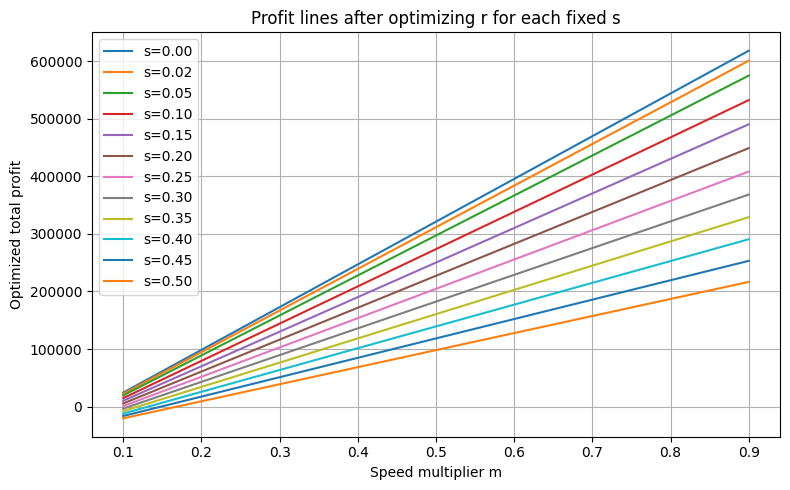

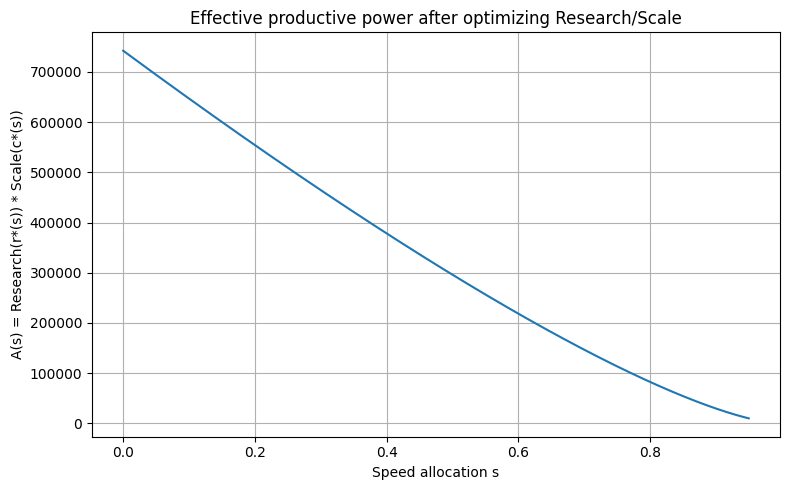

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

LOG101 = math.log(101.0)
BUDGET = 50_000.0


def research(r: float) -> float:
    return 200_000.0 * math.log(1.0 + 100.0 * r) / LOG101


def scale(c: float) -> float:
    return 7.0 * c


def fprime(r: float, s: float) -> float:
    # derivative of (1-s-r)*log(1+100r)
    return -math.log(1.0 + 100.0 * r) + 100.0 * (1.0 - s - r) / (1.0 + 100.0 * r)


def solve_r_star(s: float, tol: float = 1e-12) -> float:
    """
    Solve for r*(s) on [0, 1-s] by bisection.
    """
    if s >= 1.0:
        return 0.0

    left = 0.0
    right = 1.0 - s

    f_left = fprime(left, s)
    f_right = fprime(right, s)

    if f_left <= 0:
        return left
    if f_right >= 0:
        return right

    while right - left > tol:
        mid = 0.5 * (left + right)
        if fprime(mid, s) > 0:
            left = mid
        else:
            right = mid
    return 0.5 * (left + right)


def slope_A(s: float) -> float:
    """
    A(s) = Research(r*(s)) * Scale(c*(s))
    so that optimized profit line is Pi_s(m) = A(s)*m - 50000.
    """
    r_star = solve_r_star(s)
    c_star = 1.0 - s - r_star
    return research(r_star) * scale(c_star)


def optimized_components(s: float):
    r_star = solve_r_star(s)
    c_star = 1.0 - s - r_star
    A = research(r_star) * scale(c_star)
    return r_star, c_star, A


def profit_line(s: float, m: np.ndarray) -> np.ndarray:
    A = slope_A(s)
    return A * m - BUDGET


def main():
    # Choose several candidate speed allocations
    s_values = [0.00, 0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
    m_grid = np.linspace(0.1, 0.9, 300)

    print("s      r*(s)      c*(s)      A(s)")
    print("-" * 42)
    for s in s_values:
        r_star, c_star, A = optimized_components(s)
        print(f"{s:0.2f}   {r_star:0.6f}   {c_star:0.6f}   {A:0.2f}")

    # Plot profit lines versus m
    plt.figure(figsize=(8, 5))
    for s in s_values:
        plt.plot(m_grid, profit_line(s, m_grid), label=f"s={s:.2f}")
    plt.xlabel("Speed multiplier m")
    plt.ylabel("Optimized total profit")
    plt.title("Profit lines after optimizing r for each fixed s")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot A(s) versus s
    s_grid = np.linspace(0.0, 0.95, 300)
    A_grid = np.array([slope_A(s) for s in s_grid])

    plt.figure(figsize=(8, 5))
    plt.plot(s_grid, A_grid)
    plt.xlabel("Speed allocation s")
    plt.ylabel("A(s) = Research(r*(s)) * Scale(c*(s))")
    plt.title("Effective productive power after optimizing Research/Scale")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

### Stage II: Simulation assuming uniform distribution
Now this graph only proves my point on the break_even point. Though we do see that the slope higher for smaller s, its hard to see the actual profit from the two graphs. Hence, we should consider simulation:
1. Generate N=5000 players.
2. Sample each player’s speed allocation s from [0,0.50].
3. For each sampled s, compute the optimal $r^∗(s)$ and $c^∗(s)=1−s−r^∗(s)$.
4. Rank players by s.
5. Convert rank to multiplier m linearly from 0.9 down to 0.1.
6. Compute each player’s final profit.

=== Continuous-uniform s in [0.00, 0.50] ===
Summary statistics
--------------------------------------------------
Number of players      : 5000
Mean profit            : 59,349.59
Median profit          : 74,307.72
Std profit             : 49,514.30
Min profit             : -49,999.63
Max profit             : 114,128.82
Fraction profitable    : 0.8334
Mean speed multiplier  : 0.5000
Min/Max s              : 0.0005 / 0.9998

Profit percentile  1% : -49,567.51
Profit percentile  5% : -41,069.99
Profit percentile 10% : -24,702.40
Profit percentile 25% : 27,746.86
Profit percentile 50% : 74,307.72
Profit percentile 75% : 103,168.17
Profit percentile 90% : 110,562.90
Profit percentile 95% : 112,017.94
Profit percentile 99% : 113,730.85


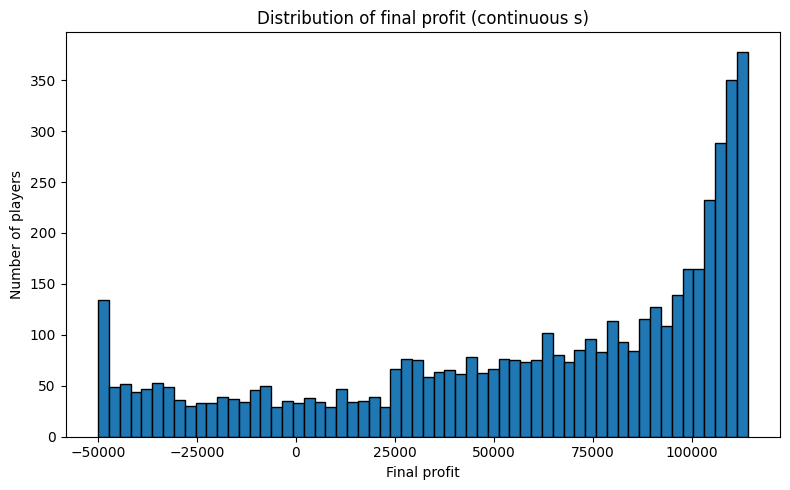

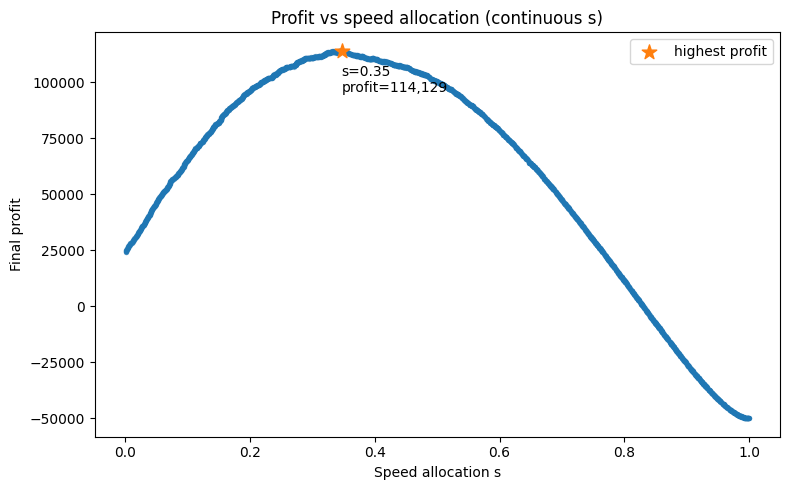

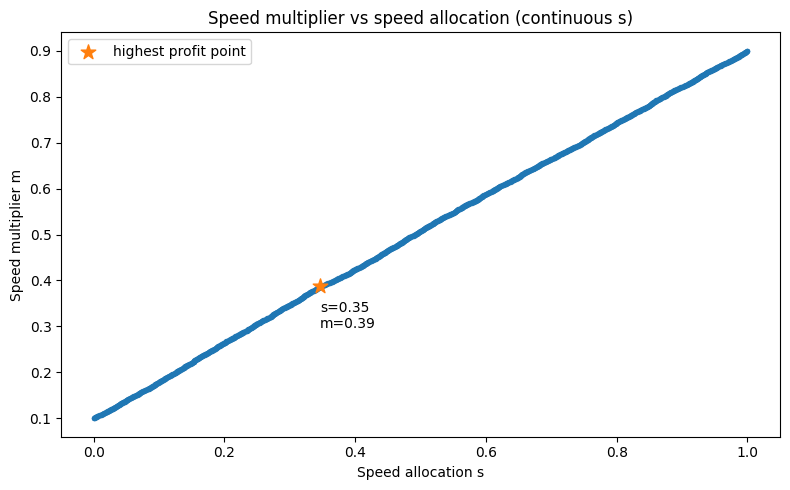


=== Discrete-uniform s in {0.00, 0.01, ..., 0.50} ===
Summary statistics
--------------------------------------------------
Number of players      : 5000
Mean profit            : 59,319.68
Median profit          : 75,702.18
Std profit             : 50,826.08
Min profit             : -50,000.00
Max profit             : 114,307.29
Fraction profitable    : 0.8192
Mean speed multiplier  : 0.5040
Min/Max s              : 0.0000 / 1.0000

Profit percentile  1% : -50,000.00
Profit percentile  5% : -43,978.38
Profit percentile 10% : -29,198.48
Profit percentile 25% : 29,590.36
Profit percentile 50% : 75,702.18
Profit percentile 75% : 104,233.53
Profit percentile 90% : 110,988.04
Profit percentile 95% : 112,775.94
Profit percentile 99% : 114,307.29

Highest-profit point
--------------------------------------------------
index      : 196
s          : 0.3400
r*         : 0.163789
c*         : 0.496211
m          : 0.382296
A          : 429,790.25
profit     : 114,307.29


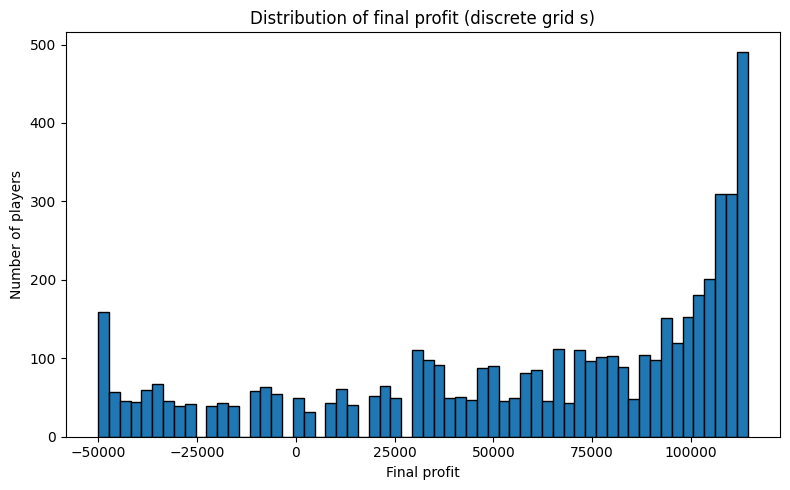

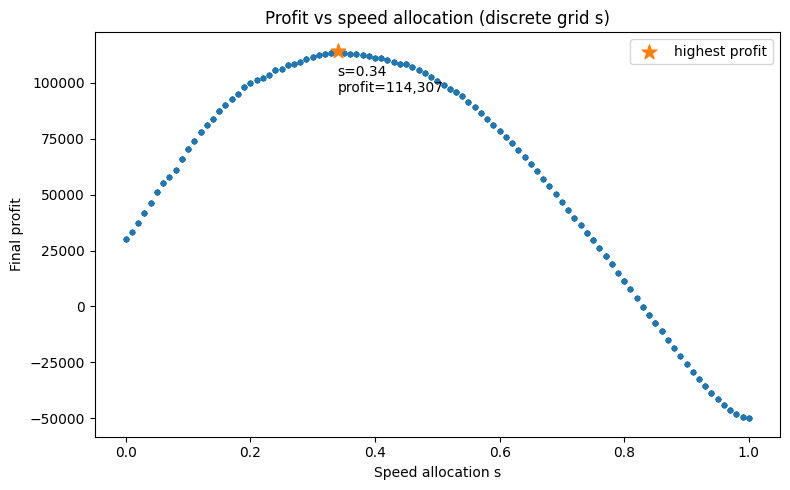

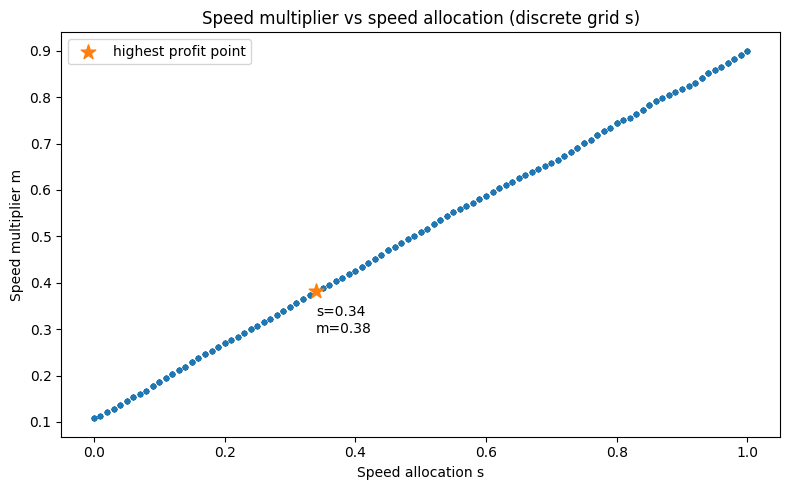

In [7]:
import math
import numpy as np
import matplotlib.pyplot as plt

BUDGET = 50_000.0
LOG101 = math.log(101.0)


def research(r: float) -> float:
    if r < 0 or r > 1:
        return -float("inf")
    return 200_000.0 * math.log(1.0 + 100.0 * r) / LOG101


def scale(c: float) -> float:
    if c < 0 or c > 1:
        return -float("inf")
    return 7.0 * c


def productive_power(r: float, c: float) -> float:
    return research(r) * scale(c)


def pnl(r: float, c: float, s: float, m: float) -> float:
    if min(r, c, s) < 0 or r + c + s > 1:
        return -float("inf")
    return research(r) * scale(c) * m - BUDGET * (r + c + s)


def first_order_equation(r: float, s: float) -> float:
    return -math.log(1.0 + 100.0 * r) + 100.0 * (1.0 - s - r) / (1.0 + 100.0 * r)


def solve_r_for_fixed_s(s: float, tol: float = 1e-12, max_iter: int = 1000) -> float:
    if not (0.0 <= s <= 1.0):
        raise ValueError("s must lie in [0,1].")
    if s >= 1.0:
        return 0.0

    left = 0.0
    right = 1.0 - s

    f_left = first_order_equation(left, s)
    f_right = first_order_equation(right, s)

    if f_left <= 0:
        return left
    if f_right >= 0:
        return right

    for _ in range(max_iter):
        mid = 0.5 * (left + right)
        f_mid = first_order_equation(mid, s)

        if abs(f_mid) < tol or (right - left) < tol:
            return mid

        if f_mid > 0:
            left = mid
        else:
            right = mid

    return 0.5 * (left + right)


def solve_fixed_s(s: float) -> tuple[float, float]:
    r_star = solve_r_for_fixed_s(s)
    c_star = 1.0 - s - r_star
    return r_star, c_star


def rank_to_multiplier_from_ranks(ranks: np.ndarray, n_players: int) -> np.ndarray:
    """
    Highest rank = 1 gets 0.9
    Lowest rank = n_players gets 0.1
    Linear scaling in between:
        m = 0.9 - 0.8 * (rank - 1) / (n_players - 1)
    """
    if n_players == 1:
        return np.array([0.9])
    return 0.9 - 0.8 * (ranks - 1) / (n_players - 1)


def competition_ranks_desc(values: np.ndarray) -> np.ndarray:
    """
    Competition ranking for descending values:
    equal values share the same rank, and next rank skips accordingly.
    Example:
        values = [70,70,70,50,40,40,30]
        ranks  = [1, 1, 1, 4, 5, 5, 7]
    """
    order = np.argsort(-values)  # descending
    sorted_vals = values[order]

    ranks_sorted = np.empty(len(values), dtype=int)
    current_rank = 1
    ranks_sorted[0] = current_rank

    for i in range(1, len(values)):
        if sorted_vals[i] == sorted_vals[i - 1]:
            ranks_sorted[i] = current_rank
        else:
            current_rank = i + 1
            ranks_sorted[i] = current_rank

    ranks = np.empty(len(values), dtype=int)
    ranks[order] = ranks_sorted
    return ranks


def simulate_players(
    n_players: int = 5000,
    s_min: float = 0.00,
    s_max: float = 0.50,
    seed: int = 42,
    mode: str = "continuous",
    grid_step: float = 0.01,
):
    """
    mode = "continuous":
        s is sampled uniformly from [s_min, s_max], so ties are essentially absent.

    mode = "discrete":
        s is sampled uniformly from {s_min, s_min+grid_step, ..., s_max},
        so ties are common and rank-sharing happens.
    """
    rng = np.random.default_rng(seed)

    if mode == "continuous":
        s_vals = rng.uniform(s_min, s_max, size=n_players)
    elif mode == "discrete":
        grid = np.round(np.arange(s_min, s_max + 1e-12, grid_step), 10)
        s_vals = rng.choice(grid, size=n_players, replace=True)
    else:
        raise ValueError("mode must be 'continuous' or 'discrete'")

    r_vals = np.empty(n_players)
    c_vals = np.empty(n_players)
    A_vals = np.empty(n_players)

    for i, s in enumerate(s_vals):
        r_star, c_star = solve_fixed_s(float(s))
        r_vals[i] = r_star
        c_vals[i] = c_star
        A_vals[i] = productive_power(r_star, c_star)

    ranks = competition_ranks_desc(s_vals)
    m_vals = rank_to_multiplier_from_ranks(ranks, n_players)
    profit_vals = A_vals * m_vals - BUDGET * (r_vals + c_vals + s_vals)

    return {
        "s": s_vals,
        "r": r_vals,
        "c": c_vals,
        "A": A_vals,
        "rank": ranks,
        "m": m_vals,
        "profit": profit_vals,
    }


def summarize_results(results: dict):
    profit = results["profit"]
    m_vals = results["m"]
    s_vals = results["s"]

    print("Summary statistics")
    print("-" * 50)
    print(f"Number of players      : {len(profit)}")
    print(f"Mean profit            : {np.mean(profit):,.2f}")
    print(f"Median profit          : {np.median(profit):,.2f}")
    print(f"Std profit             : {np.std(profit):,.2f}")
    print(f"Min profit             : {np.min(profit):,.2f}")
    print(f"Max profit             : {np.max(profit):,.2f}")
    print(f"Fraction profitable    : {np.mean(profit > 0):.4f}")
    print(f"Mean speed multiplier  : {np.mean(m_vals):.4f}")
    print(f"Min/Max s              : {np.min(s_vals):.4f} / {np.max(s_vals):.4f}")
    print()

    for q in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
        print(f"Profit percentile {q:>2}% : {np.percentile(profit, q):,.2f}")


def report_best_point(results: dict):
    s_vals = results["s"]
    m_vals = results["m"]
    profit_vals = results["profit"]
    r_vals = results["r"]
    c_vals = results["c"]
    A_vals = results["A"]

    idx = np.argmax(profit_vals)

    print("\nHighest-profit point")
    print("-" * 50)
    print(f"index      : {idx}")
    print(f"s          : {s_vals[idx]:.4f}")
    print(f"r*         : {r_vals[idx]:.6f}")
    print(f"c*         : {c_vals[idx]:.6f}")
    print(f"m          : {m_vals[idx]:.6f}")
    print(f"A          : {A_vals[idx]:,.2f}")
    print(f"profit     : {profit_vals[idx]:,.2f}")

    return idx


def plot_results(results: dict, title_suffix: str = ""):
    s_vals = results["s"]
    m_vals = results["m"]
    profit = results["profit"]

    best_idx = np.argmax(profit)
    best_s = s_vals[best_idx]
    best_m = m_vals[best_idx]
    best_profit = profit[best_idx]

    plt.figure(figsize=(8, 5))
    plt.hist(profit, bins=60, edgecolor="black")
    plt.xlabel("Final profit")
    plt.ylabel("Number of players")
    plt.title(f"Distribution of final profit{title_suffix}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.scatter(s_vals, profit, s=8, alpha=0.35)
    plt.scatter([best_s], [best_profit], s=120, marker="*", label="highest profit")
    plt.annotate(
        f"s={best_s:.2f}\nprofit={best_profit:,.0f}",
        (best_s, best_profit),
        xytext=(0, -30),
        textcoords="offset points",
    )
    plt.xlabel("Speed allocation s")
    plt.ylabel("Final profit")
    plt.title(f"Profit vs speed allocation{title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.scatter(s_vals, m_vals, s=8, alpha=0.35)
    plt.scatter([best_s], [best_m], s=120, marker="*", label="highest profit point")
    plt.annotate(
        f"s={best_s:.2f}\nm={best_m:.2f}",
        (best_s, best_m),
        xytext=(0, -30),
        textcoords="offset points",
    )
    plt.xlabel("Speed allocation s")
    plt.ylabel("Speed multiplier m")
    plt.title(f"Speed multiplier vs speed allocation{title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    N = 5000

    print("=== Continuous-uniform s in [0.00, 0.50] ===")
    results_cont = simulate_players(
        n_players=N,
        s_min=0.00,
        s_max=1.00,
        seed=42,
        mode="continuous",
        grid_step=0.01,
    )
    summarize_results(results_cont)
    plot_results(results_cont, title_suffix=" (continuous s)")

    print("\n=== Discrete-uniform s in {0.00, 0.01, ..., 0.50} ===")
    results_disc = simulate_players(
        n_players=N,
        s_min=0.00,
        s_max=1.00,
        seed=42,
        mode="discrete",
        grid_step=0.01,
    )
    summarize_results(results_disc)
    best_idx = report_best_point(results_disc)
    plot_results(results_disc, title_suffix=" (discrete grid s)")

### Stage III: Simulation assuming our opponents knows 0.34


Summary statistics
--------------------------------------------------
Number of players      : 5000
Mean profit            : 192,682.49
Median profit          : 244,576.98
Min profit             : 8,792.98
Max profit             : 244,576.98
Fraction profitable    : 1.0000
Mean speed multiplier  : 0.6116
Mass at s=0.34         : 0.5236

Group statistics for s=0.34
--------------------------------------------------
count       : 2618
rank        : 1342
multiplier  : 0.685397
mean profit : 244,576.98
min profit  : 244,576.98
max profit  : 244,576.98
best s = 0.34
best profit = 244,576.98
best m = 0.6854


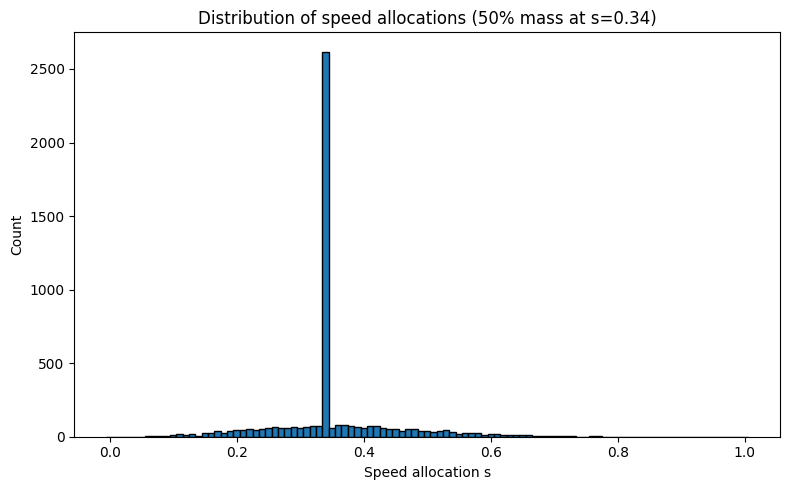

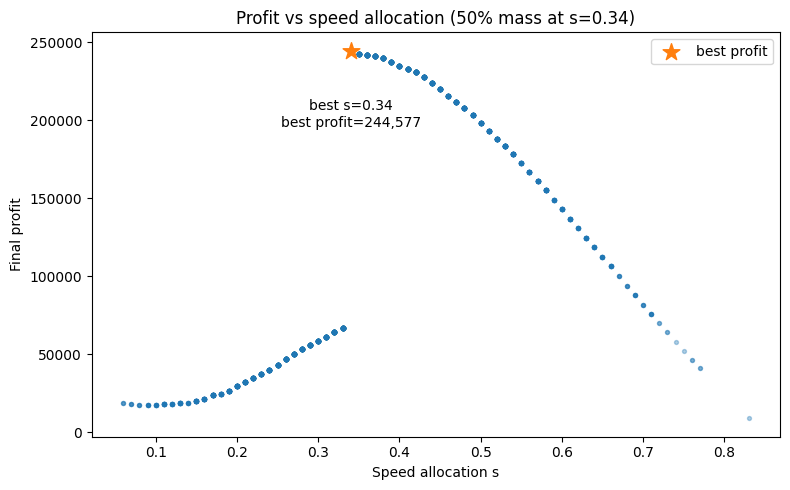

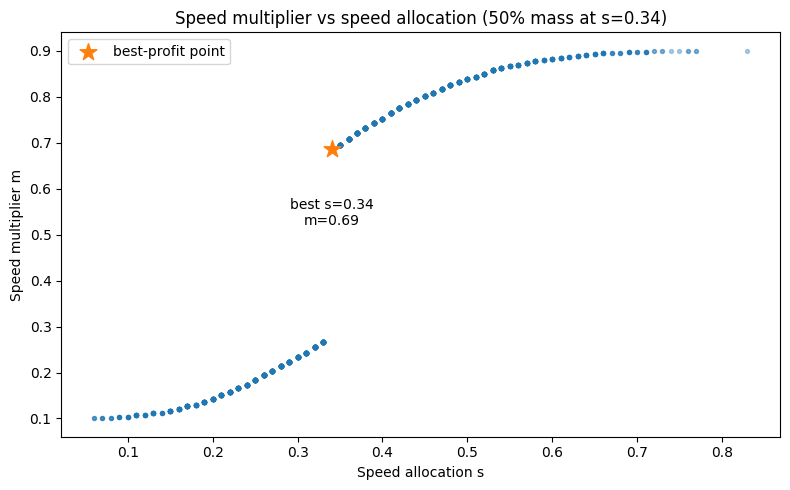

In [11]:
import math
import numpy as np
import matplotlib.pyplot as plt

BUDGET = 50_000.0
LOG101 = math.log(101.0)


def research(r: float) -> float:
    if r < 0 or r > 1:
        return -float("inf")
    return 200_000.0 * math.log(1.0 + 100.0 * r) / LOG101


def scale(c: float) -> float:
    if c < 0 or c > 1:
        return -float("inf")
    return 7.0 * c


def productive_power(r: float, c: float) -> float:
    return research(r) * scale(c)


def pnl(r: float, c: float, s: float, m: float) -> float:
    if min(r, c, s) < 0 or r + c + s > 1:
        return -float("inf")
    return research(r) * scale(c) * m - BUDGET * (r + c + s)


def first_order_equation(r: float, s: float) -> float:
    return -math.log(1.0 + 100.0 * r) + 100.0 * (1.0 - s - r) / (1.0 + 100.0 * r)


def solve_r_for_fixed_s(s: float, tol: float = 1e-12, max_iter: int = 1000) -> float:
    if not (0.0 <= s <= 1.0):
        raise ValueError("s must lie in [0,1].")
    if s >= 1.0:
        return 0.0

    left = 0.0
    right = 1.0 - s

    f_left = first_order_equation(left, s)
    f_right = first_order_equation(right, s)

    if f_left <= 0:
        return left
    if f_right >= 0:
        return right

    for _ in range(max_iter):
        mid = 0.5 * (left + right)
        f_mid = first_order_equation(mid, s)

        if abs(f_mid) < tol or (right - left) < tol:
            return mid

        if f_mid > 0:
            left = mid
        else:
            right = mid

    return 0.5 * (left + right)


def solve_fixed_s(s: float) -> tuple[float, float]:
    r_star = solve_r_for_fixed_s(s)
    c_star = 1.0 - s - r_star
    return r_star, c_star


def rank_to_multiplier_from_ranks(ranks: np.ndarray, n_players: int) -> np.ndarray:
    if n_players == 1:
        return np.array([0.9])
    return 0.9 - 0.8 * (ranks - 1) / (n_players - 1)


def competition_ranks_desc(values: np.ndarray) -> np.ndarray:
    order = np.argsort(-values)  # descending
    sorted_vals = values[order]

    ranks_sorted = np.empty(len(values), dtype=int)
    current_rank = 1
    ranks_sorted[0] = current_rank

    for i in range(1, len(values)):
        if sorted_vals[i] == sorted_vals[i - 1]:
            ranks_sorted[i] = current_rank
        else:
            current_rank = i + 1
            ranks_sorted[i] = current_rank

    ranks = np.empty(len(values), dtype=int)
    ranks[order] = ranks_sorted
    return ranks


def beta_params_from_mode(mode: float, concentration: float) -> tuple[float, float]:
    """
    Choose alpha, beta > 1 so that the Beta distribution has the requested mode:
        mode = (alpha - 1) / (alpha + beta - 2)
    and alpha + beta = concentration.
    """
    if not (0 < mode < 1):
        raise ValueError("mode must lie strictly between 0 and 1")
    if concentration <= 2:
        raise ValueError("concentration must be > 2")

    alpha = 1 + mode * (concentration - 2)
    beta = concentration - alpha
    return alpha, beta


def sample_s_mixture_peak(
    n_players: int,
    peak_s: float = 0.34,
    point_mass_prob: float = 0.50,
    concentration: float = 12.0,
    grid_step: float = 0.01,
    seed: int = 42,
) -> np.ndarray:
    """
    Mixture model:
    - with probability point_mass_prob, choose exactly peak_s
    - otherwise choose from a Beta distribution on [0,1]
      with mode near peak_s, then round to the discrete grid

    This gives:
    - at least roughly point_mass_prob mass at exactly peak_s
    - asymmetric shape around peak_s
    """
    rng = np.random.default_rng(seed)

    peak_s = round(peak_s / grid_step) * grid_step
    alpha, beta = beta_params_from_mode(peak_s, concentration)

    is_mass = rng.random(n_players) < point_mass_prob
    s_vals = np.empty(n_players)

    # Exact point mass at peak_s
    s_vals[is_mass] = peak_s

    # Remaining players sampled from beta, then rounded to 0.01 grid
    n_rest = np.sum(~is_mass)
    sampled = rng.beta(alpha, beta, size=n_rest)
    sampled = np.round(sampled / grid_step) * grid_step
    sampled = np.clip(sampled, 0.0, 1.0)

    s_vals[~is_mass] = sampled
    return s_vals


def simulate_from_given_s(s_vals: np.ndarray):
    n_players = len(s_vals)

    r_vals = np.empty(n_players)
    c_vals = np.empty(n_players)
    A_vals = np.empty(n_players)

    for i, s in enumerate(s_vals):
        r_star, c_star = solve_fixed_s(float(s))
        r_vals[i] = r_star
        c_vals[i] = c_star
        A_vals[i] = productive_power(r_star, c_star)

    ranks = competition_ranks_desc(s_vals)
    m_vals = rank_to_multiplier_from_ranks(ranks, n_players)
    profit_vals = A_vals * m_vals - BUDGET * (r_vals + c_vals + s_vals)

    return {
        "s": s_vals,
        "r": r_vals,
        "c": c_vals,
        "A": A_vals,
        "rank": ranks,
        "m": m_vals,
        "profit": profit_vals,
    }


def summarize_results(results: dict):
    s_vals = results["s"]
    profit = results["profit"]
    m_vals = results["m"]

    print("Summary statistics")
    print("-" * 50)
    print(f"Number of players      : {len(profit)}")
    print(f"Mean profit            : {np.mean(profit):,.2f}")
    print(f"Median profit          : {np.median(profit):,.2f}")
    print(f"Min profit             : {np.min(profit):,.2f}")
    print(f"Max profit             : {np.max(profit):,.2f}")
    print(f"Fraction profitable    : {np.mean(profit > 0):.4f}")
    print(f"Mean speed multiplier  : {np.mean(m_vals):.4f}")
    print(f"Mass at s=0.34         : {np.mean(np.isclose(s_vals, 0.34)):.4f}")


def report_group_at_s(results: dict, target_s: float = 0.34):
    mask = np.isclose(results["s"], target_s)
    if not np.any(mask):
        print(f"\nNo players at s={target_s:.2f}")
        return

    print(f"\nGroup statistics for s={target_s:.2f}")
    print("-" * 50)
    print(f"count       : {np.sum(mask)}")
    print(f"rank        : {results['rank'][mask][0]}")
    print(f"multiplier  : {results['m'][mask][0]:.6f}")
    print(f"mean profit : {np.mean(results['profit'][mask]):,.2f}")
    print(f"min profit  : {np.min(results['profit'][mask]):,.2f}")
    print(f"max profit  : {np.max(results['profit'][mask]):,.2f}")


def plot_results(results: dict, title_suffix: str = ""):
    s_vals = results["s"]
    m_vals = results["m"]
    profit = results["profit"]

    best_idx = np.argmax(profit)
    best_s = s_vals[best_idx]
    best_m = m_vals[best_idx]
    best_profit = profit[best_idx]

    plt.figure(figsize=(8, 5))
    plt.hist(s_vals, bins=np.arange(-0.005, 1.015, 0.01), edgecolor="black")
    plt.xlabel("Speed allocation s")
    plt.ylabel("Count")
    plt.title(f"Distribution of speed allocations{title_suffix}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.scatter(s_vals, profit, s=8, alpha=0.35)
    plt.scatter([best_s], [best_profit], s=160, marker="*", label="best profit")
    plt.annotate(
        f"best s={best_s:.2f}\nbest profit={best_profit:,.0f}",
        (best_s, best_profit),
        xytext=(0, -35),
        textcoords="offset points",
        ha="center",
        va="top",
    )
    plt.xlabel("Speed allocation s")
    plt.ylabel("Final profit")
    plt.title(f"Profit vs speed allocation{title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.scatter(s_vals, m_vals, s=8, alpha=0.35)
    plt.scatter([best_s], [best_m], s=160, marker="*", label="best-profit point")
    plt.annotate(
        f"best s={best_s:.2f}\nm={best_m:.2f}",
        (best_s, best_m),
        xytext=(0, -35),
        textcoords="offset points",
        ha="center",
        va="top",
    )
    plt.xlabel("Speed allocation s")
    plt.ylabel("Speed multiplier m")
    plt.title(f"Speed multiplier vs speed allocation{title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    N = 5000

    s_vals = sample_s_mixture_peak(
        n_players=N,
        peak_s=0.34,          # pile-up point
        point_mass_prob=0.50, # at least about 50% choose exactly 0.34
        concentration=12.0,   # controls how concentrated the rest are around 0.34
        grid_step=0.01,
        seed=42,
    )

    results = simulate_from_given_s(s_vals)

    summarize_results(results)
    report_group_at_s(results, target_s=0.34)
    best_idx = np.argmax(results["profit"])
    print(f"best s = {results['s'][best_idx]:.2f}")
    print(f"best profit = {results['profit'][best_idx]:,.2f}")
    print(f"best m = {results['m'][best_idx]:.4f}")
    plot_results(results, title_suffix=" (50% mass at s=0.34)")